In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
dataset_path="/content/drive/MyDrive/dataset1 june 3"

In [9]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

num_classes = len(train_ds.class_names)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [6]:
base_model = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
model = Sequential([

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

In [19]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.8555 - loss: 0.3758 - val_accuracy: 0.9563 - val_loss: 0.1435
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9781 - loss: 0.0872 - val_accuracy: 0.9719 - val_loss: 0.1113
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9859 - loss: 0.0486 - val_accuracy: 0.9688 - val_loss: 0.0967
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9953 - loss: 0.0242 - val_accuracy: 0.9688 - val_loss: 0.0841
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9969 - loss: 0.0159 - val_accuracy: 0.9625 - val_loss: 0.0905
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9984 - loss: 0.0148 - val_accuracy: 0.9688 - val_loss: 0.0889
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 0.9750 - val_loss: 0.0833
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9984 - loss: 0.0072 - val_accuracy: 0.9781 - val_loss

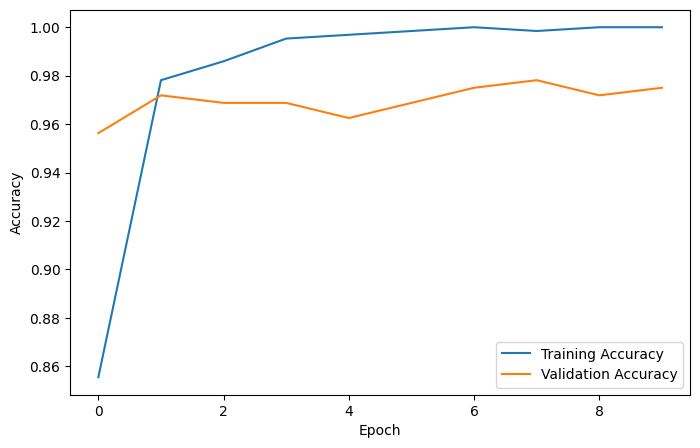

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

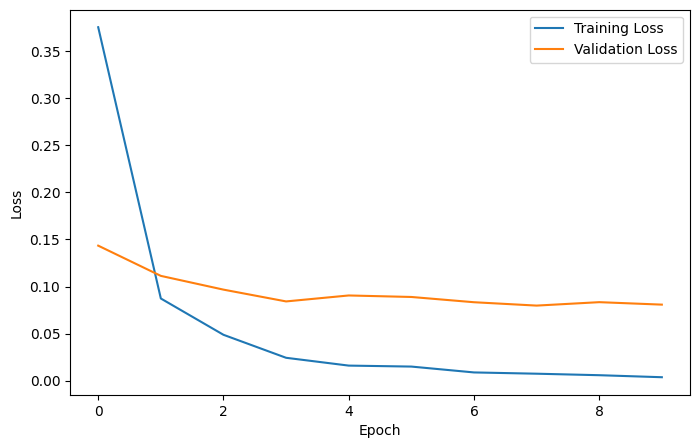

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 949ms/step - accuracy: 0.9750 - loss: 0.0807
Validation Accuracy: 0.9750000238418579


In [17]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)
    cm = confusion_matrix(y_true, y_pred)

print(cm)

[[70  0  1  0]
 [ 0 76  0  1]
 [ 2  0 77  0]
 [ 2  1  1 89]]


[[70  0  1  0]
 [ 0 76  0  1]
 [ 2  0 77  0]
 [ 2  1  1 89]]


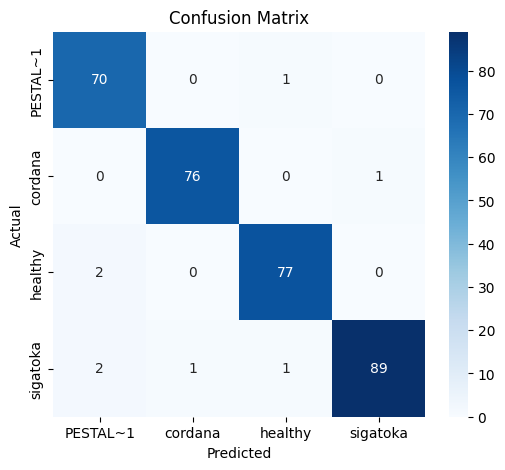

              precision    recall  f1-score   support

    PESTAL~1       0.95      0.99      0.97        71
     cordana       0.99      0.99      0.99        77
     healthy       0.97      0.97      0.97        79
    sigatoka       0.99      0.96      0.97        93

    accuracy                           0.97       320
   macro avg       0.97      0.98      0.97       320
weighted avg       0.98      0.97      0.98       320



In [20]:
import os

cm = confusion_matrix(y_true, y_pred)

# Get class names by listing subdirectories in dataset_path
class_names = sorted([name for name in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, name))])

print(cm)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))